Dataset Shape: (179078, 21)
   match_id  inning         batting_team                 bowling_team  over  \
0         1       1  Sunrisers Hyderabad  Royal Challengers Bangalore     1   
1         1       1  Sunrisers Hyderabad  Royal Challengers Bangalore     1   
2         1       1  Sunrisers Hyderabad  Royal Challengers Bangalore     1   
3         1       1  Sunrisers Hyderabad  Royal Challengers Bangalore     1   
4         1       1  Sunrisers Hyderabad  Royal Challengers Bangalore     1   

   ball    batsman non_striker    bowler  is_super_over  ...  bye_runs  \
0     1  DA Warner    S Dhawan  TS Mills              0  ...         0   
1     2  DA Warner    S Dhawan  TS Mills              0  ...         0   
2     3  DA Warner    S Dhawan  TS Mills              0  ...         0   
3     4  DA Warner    S Dhawan  TS Mills              0  ...         0   
4     5  DA Warner    S Dhawan  TS Mills              0  ...         0   

   legbye_runs  noball_runs  penalty_runs  batsman_r

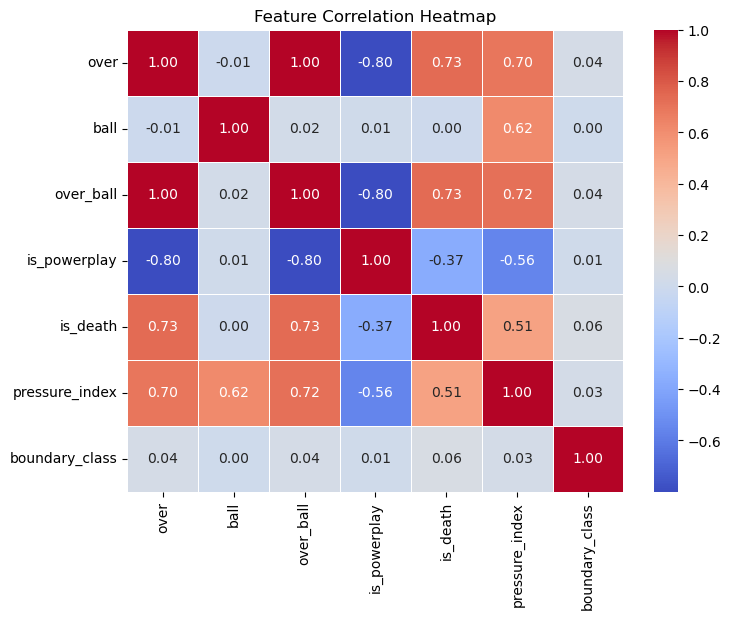


Best Parameters: {'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

--- RANDOM FOREST PERFORMANCE ---
Accuracy: 0.8405182041545678
Precision: 0.7064708515152196
Recall: 0.8405182041545678
F1 Score: 0.7676868937460287

Classification Report:


D:\ANACONDA\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\ANACONDA\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\ANACONDA\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\ANACONDA\Lib\site-packages\sklearn\metrics\_classification.py:1531: Undefine

              precision    recall  f1-score   support

           0       0.84      1.00      0.91     30104
           1       0.00      0.00      0.00      4078
           2       0.00      0.00      0.00      1634

    accuracy                           0.84     35816
   macro avg       0.28      0.33      0.30     35816
weighted avg       0.71      0.84      0.77     35816



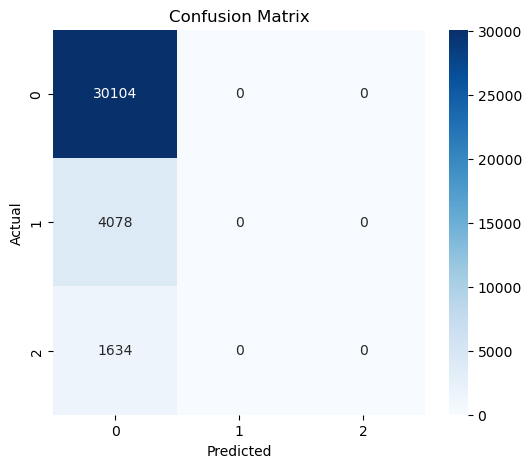


Feature Importance Table:
          Feature  Importance
0            over    0.323383
2       over_ball    0.323021
3    is_powerplay    0.115345
5  pressure_index    0.106253
4        is_death    0.081156
1            ball    0.050842


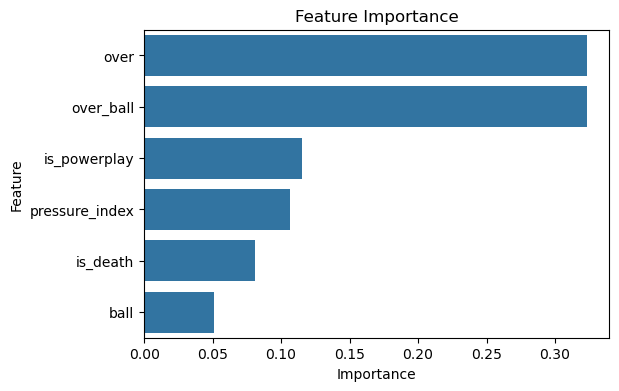

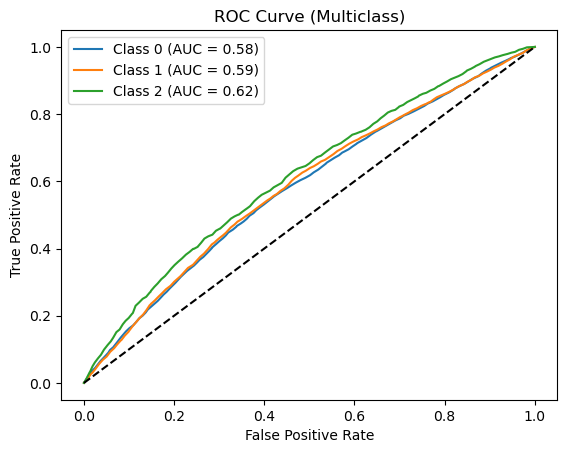


Cross Validation Scores: [0.8405182  0.84049028 0.84049028 0.84051375 0.84051375]
Mean CV Score: 0.8405052547883762


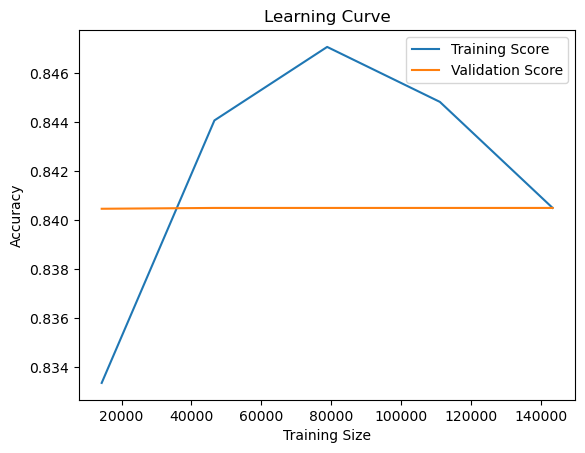


Class Distribution:
boundary_class
0    150516
1     20392
2      8170
Name: count, dtype: int64


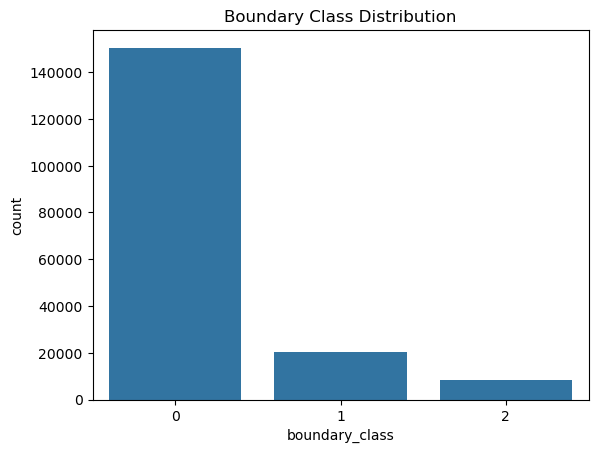

In [1]:

# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier

# 2. LOAD DATA
df = pd.read_csv("deliveries.csv")

print("Dataset Shape:", df.shape)
print(df.head())

# 3. TARGET CREATION
def classify_runs(x):
    if x == 4:
        return 1   # Four
    elif x == 6:
        return 2   # Six
    else:
        return 0   # No boundary

df['boundary_class'] = df['batsman_runs'].apply(classify_runs)

# 4. FEATURE ENGINEERING
df['over_ball'] = df['over'] + df['ball']/10
df['is_powerplay'] = df['over'].apply(lambda x: 1 if x <= 6 else 0)
df['is_death'] = df['over'].apply(lambda x: 1 if x >= 16 else 0)

# Interaction feature
df['pressure_index'] = df['over'] * df['ball']

# Selected features
features = [
    'over', 'ball', 'over_ball',
    'is_powerplay', 'is_death',
    'pressure_index'
]

X = df[features]
y = df['boundary_class']

# 4.1 FEATURE CORRELATION HEATMAP
corr_df = df[features + ['boundary_class']]
corr_matrix = corr_df.corr()

print("\nCorrelation Matrix:")
print(corr_matrix)

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)
plt.title("Feature Correlation Heatmap")
plt.show()

# 5. TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. STANDARDIZATION
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7. HYPERPARAMETER TUNING
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [8, 12, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestClassifier(random_state=42)

grid = GridSearchCV(
    rf,
    param_grid,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("\nBest Parameters:", grid.best_params_)

# 8. PREDICTIONS
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)

# 9. EVALUATION METRICS
print("\n--- RANDOM FOREST PERFORMANCE ---")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 10. CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 11. FEATURE IMPORTANCE
importances = best_model.feature_importances_

feature_table = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance Table:")
print(feature_table)

plt.figure(figsize=(6,4))
sns.barplot(x='Importance', y='Feature', data=feature_table)
plt.title("Feature Importance")
plt.show()

# 12. ROC CURVE (MULTICLASS)
y_test_bin = label_binarize(y_test, classes=[0,1,2])

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve (Multiclass)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# 13. CROSS VALIDATION
cv_scores = cross_val_score(best_model, X, y, cv=5)

print("\nCross Validation Scores:", cv_scores)
print("Mean CV Score:", cv_scores.mean())

# 14. LEARNING CURVE
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X, y, cv=5, scoring='accuracy'
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, val_mean, label="Validation Score")
plt.title("Learning Curve")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# 15. CLASS DISTRIBUTION
class_counts = df['boundary_class'].value_counts()

print("\nClass Distribution:")
print(class_counts)

sns.countplot(x='boundary_class', data=df)
plt.title("Boundary Class Distribution")
plt.show()